In [1]:
import os
os.environ["PYTHONWARNINGS"] = "ignore"

In [2]:
import warnings
warnings.filterwarnings("ignore")

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr

In [4]:
# set working directory
project_dir = "/home/cenk/BreastCancerG0arrest/"
working_dir = project_dir + "00_revisions/"
os.chdir(working_dir)

# set data directory
data_dir = working_dir + "cellline_rawdata/"

# set figure directory
figure_dir = working_dir + "figures/"

In [5]:
expression_file = data_dir + "Expression_Public_25Q2_subsetted.csv"

if not os.path.exists(expression_file):
    # Download the expression data if it does not exist
    !wget "https://depmap.org/portal/data_page/?tab=allData&releasename=DepMap%20Public%2025Q2&filename=Expression_Public_25Q2_subsetted.csv" -O "cellline_rawdata/Expression_Public_25Q2_subsetted.csv"


In [6]:
# Load the expression data
expression_data = pd.read_csv(expression_file, index_col=0)

In [7]:
# remove column GENE_title
columns_to_remove = ["depmap_id", "lineage_1", "lineage_2", "lineage_3", "lineage_6", "lineage_4"]
expression_data = expression_data.drop(columns=columns_to_remove, errors="ignore")
# # make GENE_SYMBOLS the index of the dataframe, and remove the GENE_SYMBOLS column
expression_data.index.name = "cell_line_display_name"
# expression_data = expression_data.reset_index()
expression_data = expression_data.set_index("cell_line_display_name")

In [8]:
expression_data = expression_data.T

In [9]:
cell_lines = [
    "MCF7",
    "T47D",
    "BT474",
    "ZR751",
    "MDAMB231",
    "MDAMB157",
    "HCC1937",
    "HS578T",
]
# Filter out the cell lines that are not in the expression data
expression_data = expression_data[expression_data.columns[expression_data.columns.isin(cell_lines)]]

In [10]:
import pickle

with open("gene_sets.pkl", "rb") as f:
    gene_sets = pickle.load(f)
up_genes = gene_sets["upregulated"]
down_genes = gene_sets["downregulated"]

In [11]:
def quiescence_score(
    expr_df: pd.DataFrame, up_genes: list, down_genes: list
) -> pd.Series:
    
    import numpy as np
    from scipy.stats import zscore

    # Filter gene sets for intersection with available genes
    up_genes = [g for g in up_genes if g in expr_df.index]
    down_genes = [g for g in down_genes if g in expr_df.index]
    
    if not up_genes or not down_genes:
        raise ValueError("No overlap between signature genes and expr_df index.")
    # Z-score per gene across samples/cells
    expr_z = pd.DataFrame(
        zscore(expr_df.values, axis=1, nan_policy="omit"),
        index=expr_df.index,
        columns=expr_df.columns,
    )
    # Compute gene set means (scaled by sqrt of gene count)
    up_score = expr_z.loc[up_genes].sum(axis=0) / np.sqrt(len(up_genes))
    down_score = expr_z.loc[down_genes].sum(axis=0) / np.sqrt(len(down_genes))
    # Combined quiescence score
    score = up_score - down_score
    score.name = "quiescence_score"

    return score

In [12]:
# Calculate quiescence scores
quiescence_scores = quiescence_score(expression_data, up_genes, down_genes)
quiescence_scores = quiescence_scores.rename("quiescence_score")

In [13]:
# read in experiment data
experiment_file = data_dir + "EdU-ve BRCC.csv"
experiment_data = pd.read_csv(experiment_file, header=0)

In [14]:
# remove HMEC cell line from columns
experiment_data = experiment_data.loc[:, experiment_data.columns != "HMEC"]
experiment_data = experiment_data.reset_index(drop=True)

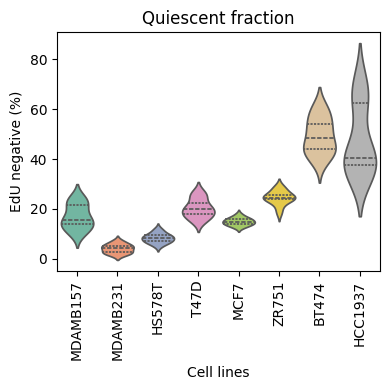

In [15]:
plt.figure(figsize=(4, 4))
order = quiescence_scores.sort_values().index
sns.violinplot(data=experiment_data[order], inner="quartile", palette="Set2")
plt.xlabel("Cell lines")
plt.xticks(rotation=90)
plt.ylabel("EdU negative (%)")
plt.title("Quiescent fraction")
plt.tight_layout()

In [16]:
# Average every 3 rows (technical replicates)
tech_avg = experiment_data.groupby(experiment_data.index // 3).mean()
# Average across resulting biological replicates
edu_negative = tech_avg.median(axis=0)
edu_negative = edu_negative.rename("edu_negative")

In [17]:
# merge the quiescence scores with the mean expression data
df = quiescence_scores.to_frame().merge(
    edu_negative.to_frame(), left_index=True, right_index=True
)

In [18]:
df["edu_fraction"] = df["edu_negative"] / 100

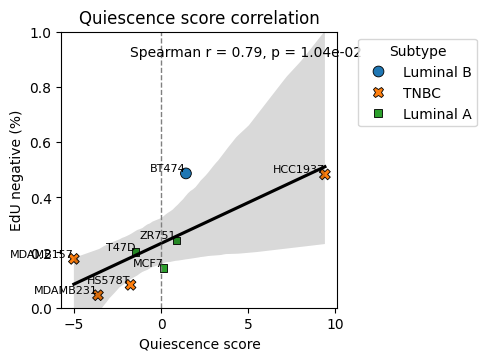

In [19]:
subtype_map = {
    "MCF7": "Luminal A",
    "BT474": "Luminal B",
    "T47D": "Luminal A",
    "ZR751": "Luminal A",
    "MDAMB231": "TNBC",
    "MDAMB157": "TNBC",
    "HCC1937": "TNBC",
    "HS578T": "TNBC",
}

df["subtype"] = df.index.map(subtype_map)

plt.figure(figsize=(5, 5))

sns.scatterplot(
    x="quiescence_score",
    y="edu_fraction",
    hue="subtype",
    style="subtype",
    data=df,
    s=60,
    edgecolor="black",
)

sns.regplot(
    x="quiescence_score",
    y="edu_fraction",
    data=df,
    scatter=False,
    color="black",
)

plt.title("Quiescence score correlation")
plt.xlabel("Quiescence score")
plt.ylabel("EdU negative (%)")

plt.axvline(x=0, color="grey", linestyle="--", linewidth=1)

r, p = spearmanr(df["edu_fraction"], df["quiescence_score"], alternative="greater")
plt.text(
    0.25,
    0.95,
    f"Spearman r = {r:.2f}, p = {p:.2e}",
    transform=plt.gca().transAxes,
    fontsize=10,
    verticalalignment="top",
)

for i, txt in enumerate(df.index):
    plt.annotate(
        txt,
        (df["quiescence_score"].iloc[i], df["edu_fraction"].iloc[i]),
        fontsize=8,
        ha="right",
        va="bottom",
    )

plt.legend(title="Subtype", bbox_to_anchor=(1.05, 1), loc="upper left")

ax = plt.gca()
ax.set_ylim(0, 1)
ax.set_box_aspect(1)

plt.tight_layout()
plt.savefig(figure_dir + "quiescence_score_vs_edu_fraction.pdf")
plt.show()

## PCAs

In [20]:
# Run PCA on expression data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(expression_data.T)
pca_df = pd.DataFrame(
    data=pca_result, columns=["PC1", "PC2"], index=expression_data.columns
)

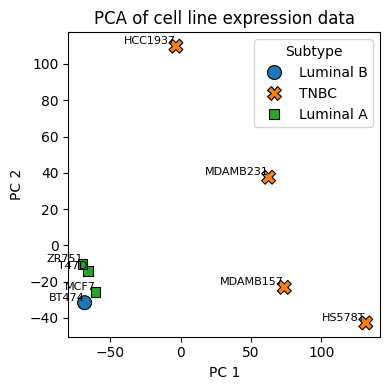

In [21]:
plt.figure(figsize=(4, 4))
# color them by subtype
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue=pca_df.index.map(subtype_map),
    style=pca_df.index.map(subtype_map),
    data=pca_df,
    s=100,
    edgecolor="black",
)

for i, txt in enumerate(pca_df.index):
    plt.annotate(
        txt,
        (pca_df["PC1"].iloc[i], pca_df["PC2"].iloc[i]),
        fontsize=8,
        ha="right",
        va="bottom",
    )

plt.title("PCA of cell line expression data")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Subtype", loc="upper right")
plt.tight_layout()
plt.grid(False)
plt.show()

In [22]:
# Run PCA on expression data
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(experiment_data.T)
pca_df = pd.DataFrame(
    data=pca_result, columns=["PC1", "PC2"], index=experiment_data.columns
)


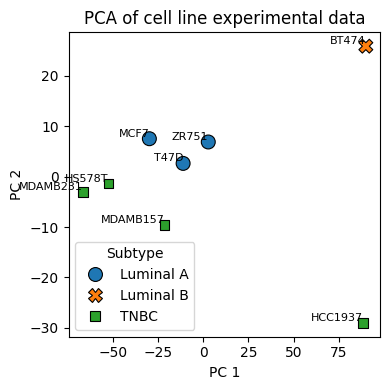

In [23]:
plt.figure(figsize=(4, 4))
# color them by subtype
sns.scatterplot(
    x="PC1",
    y="PC2",
    hue=pca_df.index.map(subtype_map),
    style=pca_df.index.map(subtype_map),
    data=pca_df,
    s=100,
    edgecolor="black",
)

for i, txt in enumerate(pca_df.index):
    plt.annotate(
        txt,
        (pca_df["PC1"].iloc[i], pca_df["PC2"].iloc[i]),
        fontsize=8,
        ha="right",
        va="bottom",
    )

plt.title("PCA of cell line experimental data")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.legend(title="Subtype", loc="lower left")
plt.tight_layout()
plt.grid(False)
plt.show()